In [12]:
!pip install yfinance

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler

In [16]:
# 1. Load Google stock data (NO CSV needed)
data = yf.download('GOOGL', start='2012-01-01', end='2020-01-01')

/tmp/ipykernel_9694/4097854805.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('GOOGL', start='2012-01-01', end='2020-01-01')
[*********************100%***********************]  1 of 1 completed


In [17]:
# Use 'Open' price
dataset = data[['Open']].values

In [18]:
# 2. Scaling
scaler = MinMaxScaler(feature_range=(0,1))
dataset_scaled = scaler.fit_transform(dataset)

In [19]:
# 3. Train-Test Split
train_size = int(len(dataset_scaled) * 0.8)
train_data = dataset_scaled[:train_size]
test_data = dataset_scaled[train_size-60:]

In [20]:
X_train, y_train = [], []
for i in range(60, len(train_data)):
  X_train.append(train_data[i-60:i, 0])
  y_train.append(train_data[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

In [22]:
# 5. Build LSTM Model
model = Sequential([ LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)),
                    Dropout(0.2),
                    LSTM(50, return_sequences=True),
                    Dropout(0.2),
                    LSTM(50),
                    Dropout(0.2),
                    Dense(1) ])

In [23]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [24]:
model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.0164
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 0.0023
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - loss: 0.0023
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - loss: 0.0019
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0020


In [25]:
# 7. Prepare Test Data
X_test, y_test = [], []
for i in range(60, len(test_data)):
  X_test.append(test_data[i-60:i, 0])
  y_test.append(test_data[i, 0])
X_test = np.array(X_test)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [26]:
# 8. Predict
predicted = model.predict(X_test)
predicted = scaler.inverse_transform(predicted)

# Real values
real = scaler.inverse_transform(test_data[60:])

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


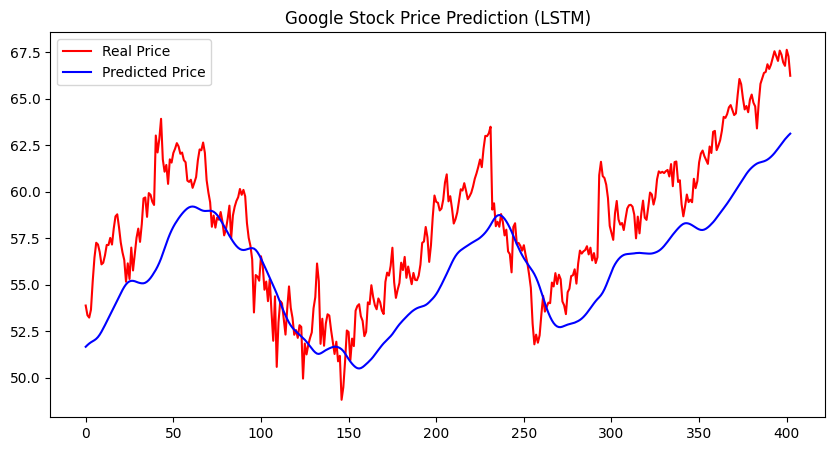

In [27]:
# 9. Plot
plt.figure(figsize=(10,5))
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')
plt.title('Google Stock Price Prediction (LSTM)')
plt.legend()
plt.show()